# 딥러닝-신경망의 이해-이항분류

In [2]:
!pip install --upgrade "numpy<2.0.0" "pandas<3.0.0" "scipy<1.12.0" "matplotlib<3.8.0"


  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.2
    Uninstalling numpy-2.2.2:
      Successfully uninstalled numpy-2.2.2
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: pandas 2.2.3 0/2 [numpy]
    Uninstalling pandas-2.2.3:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [pandas]
      Successfully uninstalled pandas-2.2.3━━━━━━━━━━━━━━━━━━━ 1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviou

In [1]:
!pip install --upgrade hossam


In [2]:
!pip install -U keras-tuner
!pip install --upgrade numpy

  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hossam 0.5.4 requires numpy<1.27,>=1.21, but you have numpy 2.4.2 which is incompatible.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.4.2 which is incompatible.
matplotlib 3.7.5 requires numpy<2,>=1.20, but you have numpy 2.4.2 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
libpysal 4.14.1 requires scipy>=1.12.0, but you have scipy 1.11.4 which is incompatible.
jax 0.7.2 requires sc

In [3]:
!pip install --upgrade hossam pandas matplotlib

  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: pandas 2.3.3 0/2 [numpy]
    Uninstalling pandas-2.3.3:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [pandas]
      Successfully uninstalled pandas-2.3.3━━━━━━━━━━━━━━━━━━━ 1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
ERROR: pip'

In [2]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from datetime import datetime as dt
from keras_tuner import Hyperband

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.losses import mse
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import AUC, F1Score

from tqdm.keras import TqdmCallback

# 로지스틱 성능평가 함수
from sklearn.metrics import confusion_matrix


## 1. 데이터 가져오기


In [5]:
origin = load_data('dogs')
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print(origin.info())
origin.head()

닥스훈트와 진돗개의 몸 길이와 키를 조사한 가상 데이터
데이터셋 크기: (200, 3)
열 개수: 3
행 개수: 200
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dog     200 non-null    str    
 1   length  200 non-null    float64
 2   height  200 non-null    float64
dtypes: float64(2), str(1)
memory usage: 5.0 KB
None


,dog,length,height
0,d,55.010,29.270
1,d,59.010,29.390
2,d,56.530,28.500
3,d,53.660,28.500
4,d,49.670,31.970


## 2. 탐색적 데이터 분석
### 1. 데이터 품질 검사

In [8]:
desc = origin.describe().T

# 숫자형 칼럼 이름만 추출
num_cols = origin.select_dtypes(include=np.number).columns

# 왜도 확인 및 로그 변환 필요성
for column in num_cols:
    skewness = origin[column].skew()
    if abs(skewness) < 0.5:
        strength = 'week'
        log_transform = 'not needed'
    elif abs(skewness) < 1:
        strength = 'normal'
        log_transform = 'recommended'
    else:
        strength = 'strong'
        log_transform = 'needed'
    
    desc.loc[column, 'skewness'] = skewness
    desc.loc[column, 'skewness_strength'] = strength
    desc.loc[column, 'log_transform'] = log_transform
desc

,count,mean,std,min,25%,50%,75%,max,skewness,skewness_strength,log_transform
length,200.000,53.795,5.506,39.940,50.222,53.445,56.900,68.310,0.224,week,not needed
height,200.000,41.675,10.036,22.760,31.965,43.785,51.185,55.870,-0.170,week,not needed


## 3. 데이터 전처리
### 1. 종속변수 라벨링

In [9]:
origin['dog'].value_counts()


dog
d    100
j    100
Name: count, dtype: int64

In [10]:
df = origin.copy()
df['dog'] = df['dog'].map({'d': 0, 'j': 1})
df['dog'].value_counts()

dog
0    100
1    100
Name: count, dtype: int64

### 2. 훈련, 검증 데이터 분리

In [31]:
yname = 'dog'
x = df.drop(columns = [yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 52)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((150, 2), (50, 2), (150,), (50,))

In [14]:
# 원래는 다중 공선성 제거도 고려해봐야 한다
_, cols = x_train.shape
cols

2

## 4. 훈련 모델 적합
### 1. 하이퍼파라미터 튜닝 함수

In [26]:
def tf_build(hp) -> Sequential:
    model = Sequential()

    # 입력층 정의
    model.add(Input(shape = (cols,)))

    # 은닉층 --> 유닛 수를 하이퍼파라미터로 조정
    model.add(
        Dense(
            units = hp.Choice('units', values = [4, 8, 16, 32, 64]),
            activation = 'relu'
        )
    )

    # 출력층: 1개의 뉴런 --> 하나의 값을 출력
    # 로지스틱 모델이기 때문에 활성화 함수는 sigmoid
    model.add(Dense(1, activation = 'sigmoid'))

    # 모델 학습 설정 (컴파일 단계)
    model.compile(
        optimizer = 'adam',
        # 이항분류이므로 손실률을 binary_crossentropy로 설정
        loss = 'binary_crossentropy',
        # accuracy: 정확도, AUC, F1Score
        metrics = ['accuracy', AUC(name = 'auc'), F1Score(name = 'f1_score')]
    )

    return model

### 2. 튜너 객체 생성

In [29]:
tuner = Hyperband(
    hypermodel = tf_build,       # 하이퍼파라미터를 튜닝하기 위한 모델 생성 함수
    objective = 'accuracy',       # 최적화 기준값
    max_epochs = 10,
    factor = 3,
    seed = 52,
    directory = 'tensor_tuning',
    project_name = 'tf_hyperband_%s' % dt.now().strftime('%Y%m%d%H%M%S')
)

tuner

### 3. 하이퍼파라미터 튜닝 수행

In [32]:
%%time

tuner.search(
    x_train, y_train, epochs = 10, batch_size = 32, validation_data = (x_test, y_test)
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters()

if not best_hps:
    raise ValueError('No best hyperparameters found')

print(f'''best hyperparameters: {best_hps[0].values}''')

Trial 5 Complete [00h 00m 04s]
accuracy: 0.5

Best accuracy So Far: 0.5
Total elapsed time: 00h 11m 43s
best hyperparameters: {'units': 4, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}
CPU times: user 9.57 s, sys: 454 ms, total: 10 s
Wall time: 10.4 s


### 4. 최종 모형 도출

In [43]:
model = tuner.hypermodel.build(best_hps[0])

result = model.fit(
    x_train,                                # 학습 데이터 입력
    y_train,                                # 학습 데이터의 타겟값 (정답)
    epochs = 500,                           # 전체 학습 데이터셋을 500회 반복하여 학습
    validation_data = (x_test, y_test),     # 검증 데이터 설정
    verbose = 0,                            # 학습 과정 출력 생략
    callbacks = [
        TqdmCallback(verbose = 1),          # 학습 진행 상황을 tqdm 형태로 보여주는 콜백 추가
        # 조기 종료 콜백
        # 너무 일찍 조기종료하면 모델이 충분히 학습되지 않고 에러율이 높게 나올 수 있음
        EarlyStopping(monitor = 'accuracy', patience = 5, min_delta = 0.001),

        # 학습률 감소 콜백: 검증 손실(val_loss)이 10회 연속 개선되지 않으면 학습률을 0.5배로 감소
        ReduceLROnPlateau(monitor = 'accuracy', factor = 0.5, patience = 10, min_lr = 0, verbose = 1)
    ]
)
result

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

## 5. 성능평가
### 1. 성능평가 지표

In [44]:
# Train 성능평가
# metrics = ['accuracy']에 의해 evaluate()가 반환하는 리스트 순서는 [loss, accuracy]
train_eval = model.evaluate(x_train, y_train, verbose = 0, return_dict = True)
test_eval = model.evaluate(x_test, y_test, verbose = 0, return_dict = True)

# DataFrame 생성
final_results = DataFrame([train_eval, test_eval])
final_results.insert(0, 'Dataset', ['Train', 'Test'])

# Gap 계산
for metric in ['loss', 'accuracy', 'auc', 'f1_score']:
    final_results[f'{metric}_gap'] = None
    final_results.loc[1, f'{metric}_gap'] = (
        final_results.loc[1, metric] - final_results.loc[0, metric]
    )

final_results

,Dataset,accuracy,auc,f1_score,loss,loss_gap,accuracy_gap,auc_gap,f1_score_gap
0,Train,0.500,0.978,0.667,0.679,None,None,None,None
1,Test,0.500,0.994,0.667,0.681,0.002,0.000,0.015,0.000


### 2. 학습 과정 확인

In [45]:
history_df = DataFrame(data = result.history)
history_df['epoch'] = history_df.index + 1

history_df.head()

,accuracy,auc,f1_score,loss,val_accuracy,val_auc,val_f1_score,val_loss,learning_rate,epoch
0,0.507,0.064,0.667,0.744,0.500,0.011,0.667,0.734,0.001,1
1,0.507,0.131,0.667,0.718,0.500,0.018,0.667,0.715,0.001,2
2,0.507,0.208,0.667,0.704,0.500,0.035,0.667,0.699,0.001,3
3,0.353,0.375,0.667,0.694,0.500,0.840,0.667,0.689,0.001,4
4,0.500,0.813,0.667,0.684,0.500,0.990,0.667,0.684,0.001,5


### 3. Loss, RMSE 학습곡선

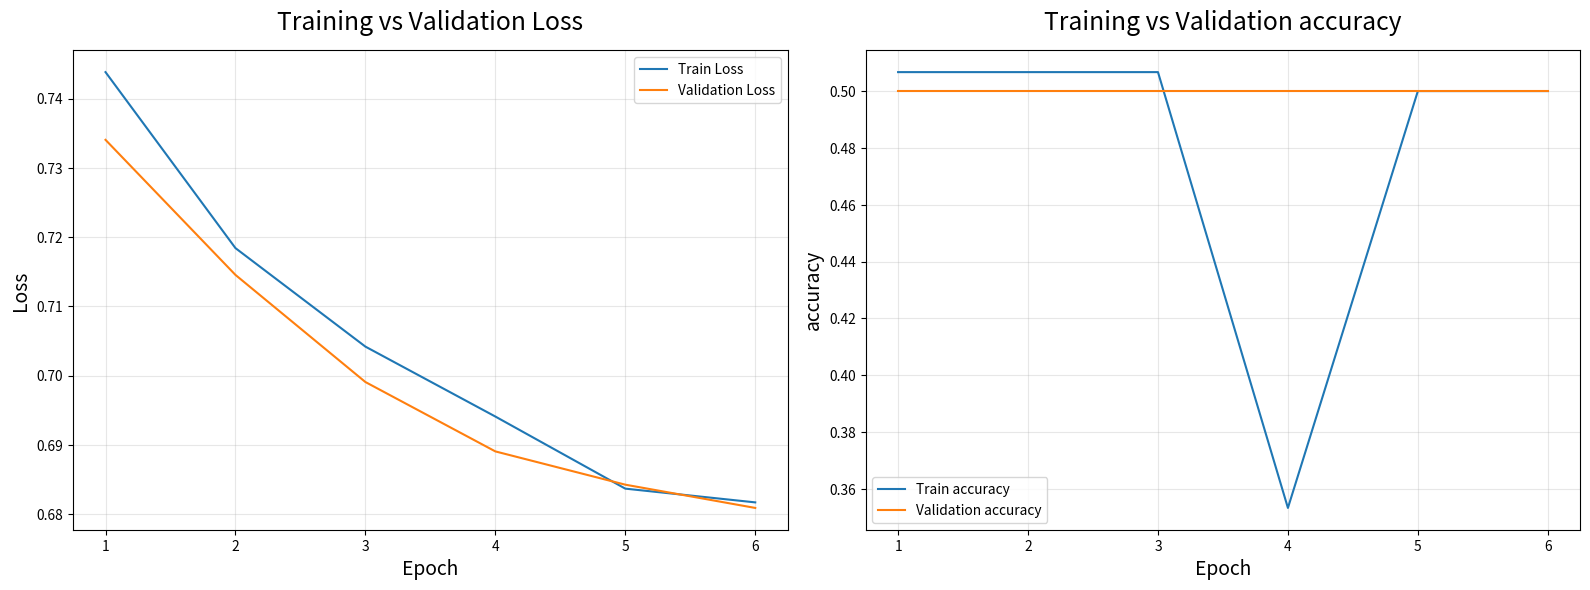

In [49]:
figsize = (1600/ 100, 600 / 100)
fig, ax = plt.subplots(1, 2, figsize = figsize, dpi = 100)
fig.subplots_adjust(wspace = 0.2, hspace = 0.2)

# 훈련 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'loss', ax = ax[0], label = 'Train Loss'
           )

# 검증 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'val_loss', ax = ax[0], label = 'Validation Loss'
           )

# 그래프 꾸미기
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training vs Validation Loss')  

ax[0].grid(True, alpha = 0.3)

# 훈련 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'accuracy', ax = ax[1], label = 'Train accuracy'
           )

# 검증 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'val_accuracy', ax = ax[1], label = 'Validation accuracy'
           )

# 그래프 꾸미기
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('accuracy')
ax[1].set_title('Training vs Validation accuracy')  

ax[1].grid(True, alpha = 0.3)

# 출력
plt.tight_layout()
plt.show()
plt.close()

## 6. 예측 결과 활용
### 1. 예측치 구하기

In [50]:
pred = model.predict(x_test, verbose = 0)
pred[:5]

array([[0.45107132],
       [0.43581992],
       [0.45070353],
       [0.4660209 ],
       [0.44864672]], dtype=float32)

### 2. 결과 데이터 셋 구성


In [55]:
kdf = DataFrame({
    '실제값': y_test,
    '분류값': pred.flatten(),
})

kdf['분류결과'] = np.where(kdf['분류값'] >= 0.5, 1, 0)

kdf.head()

,실제값,분류값,분류결과
119,1,0.451,0
62,0,0.436,0
132,1,0.451,0
114,1,0.466,0
104,1,0.449,0


### 3. 관측치와 예측치 비교 시각화

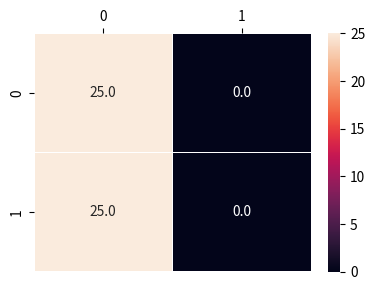

In [57]:
cm = confusion_matrix(
    kdf['실제값'],
    kdf['분류결과']
)
figsize = (400 / 100, 300 / 100)
fig, ax = plt.subplots(1, 1, figsize = figsize, dpi = 100)
sb.heatmap(data = cm, annot = True, fmt = '0.1f', linewidth = 0.5)
ax.set_xlabel('')
ax.set_ylabel('')
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()
plt.close()